In [1]:
import cupy as np
import math
import matplotlib.pyplot as plt
import scipy as sc
import importlib
import sys
sys.path.append('..')
import collision_cp
importlib.reload(collision_cp)
from collision_cp import generate_spectrum, wigner_smith_matrix, wigner_smith_matrix_single, thermal_time_delay, relative_MB_weights, S_matrix

# parameters
e_mass = 5.48579909e-4    # electron mass in amu
t0 = 315775               # a.u. to K
tau0 = 2.418884326509e-17 # a.u. to sec

In [2]:
# define properties of molecules
reduced_masses = {"NaKNaK" : 62 / 2, "RbKRb" : 87 * (87 + 40) / (87 + 87 + 40)}     # amu
van_der_wall_coeffs = {"NaKNaK" : 561070, "RbKRb" : 8000}      # a.u.

molecules = "RbCsRbCs"
mu = 51 / e_mass      # now in a.u.
c6 = 7700         # a.u.

# define natural units
beta = (2 * mu * c6) ** (1/4)    # length 
E_beta = 1 / (2 * mu * beta ** 2)   # energy
tau_beta = 2 * np.pi / E_beta    # time
print("reduced mass", mu)
print("C6", c6)
print("beta (a0)", beta)
print("E_beta (uK)", E_beta * t0 * 1e6)
print("tau_beta (s)", tau_beta * tau0)

reduced mass 92967.31280765879
C6 7700
beta (a0) 194.51932314094483
E_beta (uK) 44.88404310178714
tau_beta (s) 1.0692536510917182e-06


In [3]:
num_samples = 5000

scale = 1

# properties of resonant spectrum
rrkm = 0.39e-3 / 1e5     # seconds
dos = rrkm / tau0 / 2 / np.pi * E_beta
mean_spacing = 1 / dos / scale
print("mean spacing (E6)", mean_spacing)

# thermal properties
temp = 1 / scale       # in terms of E6
num_resonances = 1000        # should be odd
print("T/d", temp / mean_spacing)

rrkm_c6 = 2 * np.pi / mean_spacing 
print("RRKM (tau_beta)", rrkm_c6)
print("RRKM (s)", rrkm_c6 * tau_beta * tau0 / scale)

mean spacing (E6) 274.16760284403034
T/d 0.003647403958843687
RRKM (tau_beta) 0.02291731496355531
RRKM (s) 2.450442269800038e-08


In [4]:
mean_x = 1
mean_coupling_strength = np.sqrt(mean_x * mean_spacing / np.pi ** 2)

energy_GOE_mat, W_mat, x_actual = generate_spectrum(num_resonances, mean_spacing, mean_coupling_strength)

In [5]:
import pickle
with open("sparse_spectrum.pkl", "rb") as f:
    energy_GOE_mat, W_mat, x_actual = pickle.load(f)

In [97]:
hbar = 1
std_k = 1 / 3
std_x = 1 / std_k
print(std_x)
x0 = -200
print(x0)
k0 = 1
print(temp)
print(k0)
print(200 / (2 * k0))

def gaussian_envelope(k):
    normalization = 1 / np.sqrt((std_k * np.sqrt(2 * np.pi)))
    phase = np.exp(-1j * (k - k0) * x0)
    gaussian = np.exp(-((k - k0) / std_k) ** 2 / 4)
    return normalization * gaussian * phase

def wave(t, k, x):
    position = np.exp(1j * k * x)
    time_evolution = np.exp(1j * k ** 2 * t)
    return gaussian_envelope(k) * position * time_evolution / np.sqrt(2 * np.pi)

def reflected_wave(t, k, x, r):
    position = np.exp(-1j * k * x)
    time_evolution = np.exp(1j * k ** 2 * t)
    return r(k) * gaussian_envelope(k) * position * time_evolution / np.sqrt(2 * np.pi)

3.0
-200
1.0
1
100.0


In [10]:
ks = np.arange(-10, 10, 0.01)
dk = 0.01
print(np.sum(np.abs(gaussian_envelope(ks)) ** 2) * dk)
print(np.sum((ks - k0) ** 2 * np.abs(gaussian_envelope(ks)) ** 2) * dk)
mean_k2 = np.sum(ks ** 2 * np.abs(gaussian_envelope(ks)) ** 2) * dk
print("mean", mean_k2)
var_k2 = np.sum((ks ** 2 - mean_k2) ** 2 * np.abs(gaussian_envelope(ks)) ** 2) * dk
print("std", var_k2)
print(std_k ** 2)


Es = np.arange(0, 10, 0.01)
dE = 0.01
print(np.sum(Es * relative_MB_weights(0.76, Es)) * dE)
print(0.76 * 3 / 2)
print(np.sum((Es - 0.76 * 3 / 2) ** 2 * relative_MB_weights(0.76, Es)) * dE)

1.0
0.1111111111111111
mean 1.111111111111111
std 0.4691358024691358
0.1111111111111111
1.1399107027261661
1.1400000000000001
0.8651704218898216


(999,)


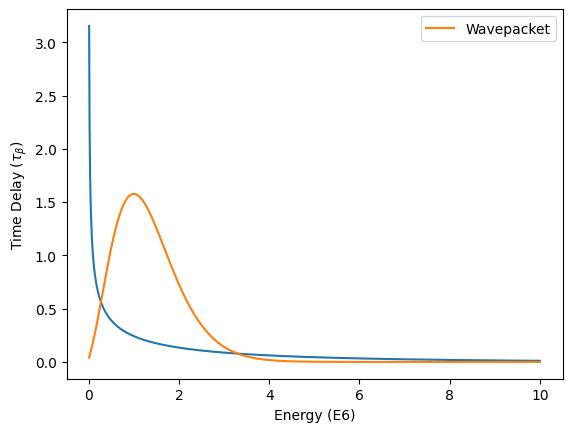

In [98]:
energy_grid = np.linspace(0, 10, 1000)[1:]
time_delays = wigner_smith_matrix(energy_grid, energy_GOE_mat, np.square(W_mat))
print(time_delays.shape)
# time_delays = (mean_spacing / 2 / np.pi) * time_delays
plt.plot(energy_grid.get(), time_delays.get())
plt.plot(energy_grid.get(), max(time_delays.get() / np.abs(gaussian_envelope(k0)).get() ** 2 / 2) * np.abs(gaussian_envelope(np.sqrt(energy_grid))).get() ** 2, label="Wavepacket")
# plt.vlines(temp, min(time_delays.get()), max(time_delays.get()), colors="red", label="temperature")
plt.legend()
plt.xlabel("Energy (E6)")
plt.ylabel(r"Time Delay ($\tau_\beta$)")
# plt.savefig("gif_wavepacket.pdf")
plt.show()

In [ ]:
# import pickle
# with open("gif.pkl", "wb") as f:
#     pickle.dump((energy_GOE_mat, W_mat, x_actual), f)

In [99]:
xs = np.linspace(10, 2010, 4001)
dx = xs[1] - xs[0]
flux_boundary = 480
print(xs[flux_boundary])

ps = np.linspace(k0 - 4 * std_k, k0 + 4 * std_k, 10001)
dp = ps[1] - ps[0]
print(dp)
ps = ps.reshape((len(ps), 1))

maxt = (100 / k0 / 2) * 10
ts = np.linspace(0, maxt * 4, 1001)
dt = ts[1] - ts[0]
print(maxt)
print(ts[300])
time_min = 0

250.0
0.0002666666666666928
500.0
600.0


In [100]:
fluxes = []
fluxes_nores = []

r1 = lambda k : 1 #* S_matrix(k ** 2, energy_GOE_mat, np.square(W_mat)).reshape((len(k), 1))
psi1 = []
normalized_gaussian = gaussian_envelope(ps) / np.sqrt(2 * np.pi)
forward_phase = np.exp(1j * ps * xs)
backward_phase = np.exp(-1j * ps * xs)

incoming_envelope = normalized_gaussian * forward_phase
outgoing_envelope = normalized_gaussian * backward_phase
reflected_envelope_1 = outgoing_envelope
total_envelope_1 = incoming_envelope + reflected_envelope_1

time_evolutions = []

for t in ts:
    time_evolution = np.exp(1j * ps ** 2 * t)
    time_evolutions.append(time_evolution)
    total_wave_1 = total_envelope_1 * time_evolution
    wave1 = np.sum(total_wave_1 * dp, axis=0)
    psi1.append(wave1)

psi1 = np.array(psi1)
flux_nores = np.sum(np.abs(psi1[:,flux_boundary:]) ** 2 * dx, axis=1).get()
fluxes_nores.append(flux_nores)
print(flux_nores[-1])

0.04917670441151042


In [101]:
import pickle 
from tqdm import tqdm

spectrum_list = []
data = {}
    # num_sectors = sectors

for i in tqdm(range(1)):
    # energy_GOE_mat, W_mat, x_actual = generate_spectrum(num_resonances, mean_spacing, mean_coupling_strength)
    # spectrum_list.append((energy_GOE_mat, W_mat, x_actual))
    
    r2 = lambda k : np.conj(S_matrix((k ** 2), energy_GOE_mat, np.square(W_mat)).reshape((len(k), 1)))

    psi2 = []
    reflected_envelope_2 = r2(ps) * outgoing_envelope
    total_envelope_2 = incoming_envelope + reflected_envelope_2
    
    for time_evolution in time_evolutions:
        total_wave_2 = total_envelope_2 * time_evolution
        wave2 = np.sum(total_wave_2, axis=0) * dp
        psi2.append(wave2)
        
    psi2 = np.array(psi2)

    flux = np.sum(np.abs(psi2[:,flux_boundary:]) ** 2 * dx, axis=1).get()
    fluxes.append(flux)
    # break

save_dict = {"fluxes" : fluxes, "flux_nores" : flux_nores}
data = save_dict
# break

# with open("wavepacket_delay_even_more.pkl", "wb") as f:
#     pickle.dump(data, f)

# print(data)

100%|██████████| 1/1 [00:38<00:00, 38.96s/it]


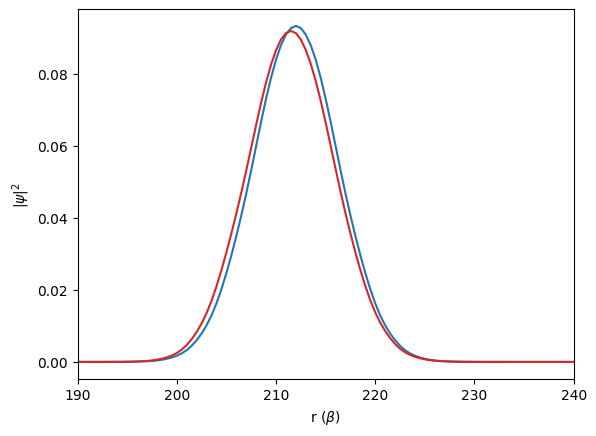

In [125]:
time_index = 3
plt.plot(xs.get(), (np.abs(psi1[time_index]) ** 2).get(), color='tab:blue')
plt.plot(xs.get(), (np.abs(psi2[time_index]) ** 2).get(), color='tab:red')
plt.xlim(190, 240)
# plt.ylim(0.0008, 0.001)
plt.xlabel(r"r ($\beta$)")
plt.ylabel(r"$|\psi|^2$")
# plt.title("t=" + str(ts[time_index]) + r" $\tau_\beta$")
plt.savefig(f"sparse_wavepacket.pdf")

436


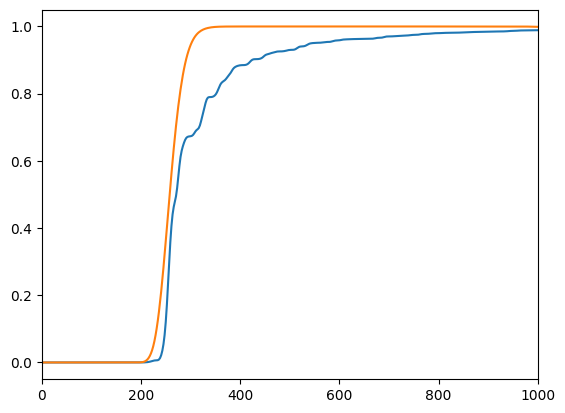

0.988942200011446


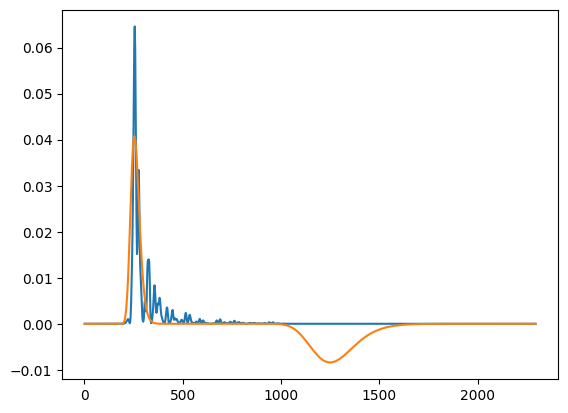

In [30]:
flux = fluxes[0]
flux_nores = save_dict["flux_nores"]
plt.plot(ts.get(), flux)
plt.plot(ts.get(), flux_nores)
plt.xlim(0, 1000)
print(np.argmax(ts > 1000))
# plt.xlim(0, ts[10])
plt.show()

pdf_nores = []
for i in range(len(flux) - 1):
    pdf_nores.append((flux_nores[i + 1] - flux_nores[i]))

pdf = []
current_max = flux[0]
for i in range(len(flux) - 1):
    if flux[i + 1] > current_max:
        pdf.append((flux[i + 1] - current_max))
        current_max = flux[i + 1]
    else:
        pdf.append(0)
plt.plot(ts[1:].get(), np.array(pdf).get())
plt.plot(ts[1:].get(), np.array(pdf_nores).get())
print(current_max)
# plt.xlim(240, 260)
# print(flux_nores[495:505])
# print(np.array(pdf_nores[240:260]))

In [ ]:
psis = [psi1]
flux_data = [flux_nores, flux]
labels = ["Undelayed", "Delayed"]

import matplotlib.animation as animation
plt.rcParams["animation.html"] = "jshtml"

i = 0
fig, ax = plt.subplots(2, 1)
fig.set_figheight(7)
lines = []
flux_plots = []
for j in range(len(psis)):
    line = ax[0].plot(xs.get(), np.abs(psis[j][i]).get() ** 2, label=labels[j])[0]
    lines.append(line)

    flux_plot = ax[1].plot(ts.get()[:i], flux_data[i][:i])[0]
    flux_plots.append(flux_plot)

ax[0].set(xlim=[0, 1000])
ax[0].legend(loc="upper right")
ax[0].set_xlabel(r"r $(a_0)$")
ax[0].set_ylabel(r"$|\psi|^2$")
ax[0].ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
# ax[0].set(ylim=[0, 0.06])

ax[1].set(xlim=[0, 700])
ax[1].set(ylim=[0, 1.2])
ax[1].set_xlabel(r"Time $(\tau_\beta)$")
ax[1].set_ylabel(r"Probability Flux")

num = 1000
line2 = ax[0].plot([250 for i in range(num)], [i / num for i in range(num)], color='red')[0]

def update(frame):
    global i
    # update the line plot:
    for j in range(len(psis)):
        lines[j].set_ydata(np.abs(psis[j][i]).get() ** 2)

        flux_plots[j].set_xdata(ts.get()[:i])
        flux_plots[j].set_ydata(flux_data[j][:i])

    ax[0].set(ylim=[0, np.max(np.abs(psis[0][i]).get() ** 2).item() * 1.6])
    # line2.set_xdata([mean1[i] for j in range(num)])
    # line3.set_xdata([mean1_g0[i] for j in range(num)])
    i += 1
    i = i % len(ts)
    return line


ani = animation.FuncAnimation(fig=fig, func=update, frames=300, interval=40)

writergif = animation.PillowWriter(fps=30)
ani.save('undelayed.gif',writer=writergif)
# ani.save('both.mp4', fps=200, dpi=100) 

ani